In [110]:
import pandas as pd
import numpy as np

import seaborn as sns

from ground_truth_comparison import euclidean_dist, match_gt_vio_ts, generate_error_gt_vio_pose

In [111]:
base_dir = '/home/shiva/Datasets/Kimera_VIO_Output'
working_dir = 'Euroc_Dataset'
execution_folder_name = '20Hz_0.25_Keyframe_Added_Noise_1'

use_output_log_dir = True

In [112]:
if use_output_log_dir:
    full_dir_path = f'{base_dir}/{working_dir}/{execution_folder_name}/output_logs'
else:
    full_dir_path = f'{base_dir}/{working_dir}/{execution_folder_name}'

In [113]:
# gt_df = pd.read_csv(f'{full_dir_path}/traj_gt.csv')
# gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)

In [114]:
df_pose_est = pd.read_csv(f'{full_dir_path}/traj_vio.csv')
df_pose_est.rename(columns={'#timestamp': 'timestamp'}, inplace=True)

In [115]:
df_pose_est

,timestamp,x,y,z,qw,qx,qy,qz,vx,vy,vz,bgx,bgy,bgz,bax,bay,baz
0,1413393214805760512,0.000000,0.000000,0.000000,0.600449,-0.004247,-0.799652,0.000000,0.000000,0.000000,0.000000,-0.000823,0.026635,0.088583,-0.001351,0.000007,0.000392
1,1413393215005760512,-0.000230,-0.000288,0.000571,0.600284,-0.003906,-0.799777,-0.000408,-0.000063,-0.000112,0.009106,-0.000873,0.026551,0.088372,0.016301,-0.000512,-0.004513
2,1413393215205760512,0.000601,-0.000248,0.001551,0.599742,-0.003398,-0.800185,-0.000975,-0.004271,-0.002631,-0.003280,-0.000961,0.026131,0.087988,0.007634,-0.000543,-0.001706
3,1413393215405760512,-0.000170,-0.000341,0.001795,0.599358,-0.003398,-0.800473,-0.001391,0.001887,0.001221,0.004199,-0.001061,0.026073,0.087972,0.015783,-0.000516,-0.004195
4,1413393215605760512,-0.000229,-0.000443,0.001842,0.598665,-0.003258,-0.800991,-0.001733,0.002317,0.003808,0.004260,-0.001023,0.025996,0.088221,0.020975,-0.000133,-0.005958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,1413393325405760512,-1.572050,-0.794450,-0.363036,-0.483916,0.456274,0.653504,0.361347,-0.002619,0.001763,0.001561,-0.002681,0.024913,0.081704,-0.014968,-0.043874,0.028179
554,1413393325605760512,-1.572349,-0.793815,-0.362760,-0.483970,0.456312,0.653297,0.361601,-0.001844,0.002322,-0.004632,-0.002681,0.024913,0.081704,-0.016797,-0.044464,0.030256
555,1413393325805760512,-1.573050,-0.793213,-0.363345,-0.484098,0.456165,0.653453,0.361334,0.000027,0.004844,-0.000054,-0.002681,0.024913,0.081704,-0.016188,-0.043784,0.032551
556,1413393326005760512,-1.573396,-0.792171,-0.362908,-0.484045,0.456170,0.653570,0.361186,-0.001691,0.004793,-0.000339,-0.002681,0.024913,0.081704,-0.015549,-0.043891,0.035102


In [116]:
df_pose_est[['x', 'y', 'z']].describe()

,x,y,z
count,558.000000,558.000000,558.000000
mean,0.871486,0.788904,0.146009
std,1.688243,1.563551,0.220295
min,-2.488748,-2.019536,-0.419457
25%,-0.218915,-0.639657,0.002577
50%,0.587891,0.587627,0.176545
75%,2.531355,2.478814,0.273056
max,3.254540,2.940310,0.747734


In [117]:
df_to_plot = df_pose_est[['timestamp', 'x', 'y', 'z']]

/tmp/ipykernel_867707/318485464.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.lineplot(x='timestamp', y='value', hue='variable',


[Text(0.5, 0, 'Timestamp'),
 Text(0, 0.5, 'Displacement(m)'),
 Text(0.5, 1.0, 'Displacement vs Time (initial_k - 50)')]

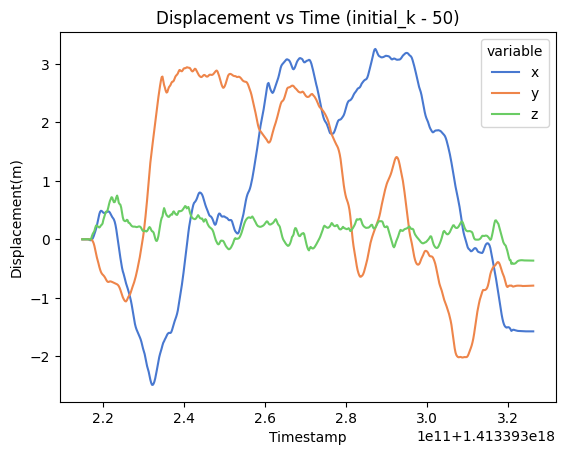

In [118]:
g = sns.lineplot(x='timestamp', y='value', hue='variable', 
             data=pd.melt(df_to_plot, ['timestamp']),
             palette=sns.color_palette("muted"))
g.set(xlabel ="Timestamp", ylabel = "Displacement(m)", title ='Displacement vs Time (initial_k - 50)')

In [119]:
# Calculating error from Euroc dataset with no modifications.
# This was already done so no need to repeat.
# We will use these results to compare performance when noise is added!

# error_df = generate_error_gt_vio_pose(gt_df, df_pose_est, DEBUG=False, SHOW_GRAPHS=False)
# values = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
#         'gt_y':error_df.iloc[-1]['gt_pos'][1],
#         'gt_z':error_df.iloc[-1]['gt_pos'][2],
#         'vio_x': error_df.iloc[-1]['vio_pos'][0],
#         'vio_y': error_df.iloc[-1]['vio_pos'][1],
#         'vio_z': error_df.iloc[-1]['vio_pos'][2],
#         'distance': error_df['distance'],
#         'error': error_df['error']
#         }
# default_v2_01_easy_results_df = pd.DataFrame(data={'Distance (m)': values['distance'], 'Error (m)':values['error']})
# default_v2_01_easy_results_df.to_csv('v2_01_easy_dist_vs_error.csv', index=False)

In [120]:
default_v2_01_easy_results_df = pd.read_csv('v2_01_easy_dist_vs_error.csv')
default_v2_01_easy_results_df['Execution'] = "Default"

In [121]:
error_df = generate_error_gt_vio_pose(gt_df, df_pose_est, DEBUG=False, SHOW_GRAPHS=False)

values = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
        'gt_y':error_df.iloc[-1]['gt_pos'][1],
        'gt_z':error_df.iloc[-1]['gt_pos'][2],
        'vio_x': error_df.iloc[-1]['vio_pos'][0],
        'vio_y': error_df.iloc[-1]['vio_pos'][1],
        'vio_z': error_df.iloc[-1]['vio_pos'][2],
        'distance': error_df['distance'],
        'error': error_df['error']
        }
added_noise_v2_01_easy_results_df = pd.DataFrame(data={'Distance (m)': values['distance'], 'Error (m)':values['error']})
added_noise_v2_01_easy_results_df['Execution'] = "Added_Noise_1"

558
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []


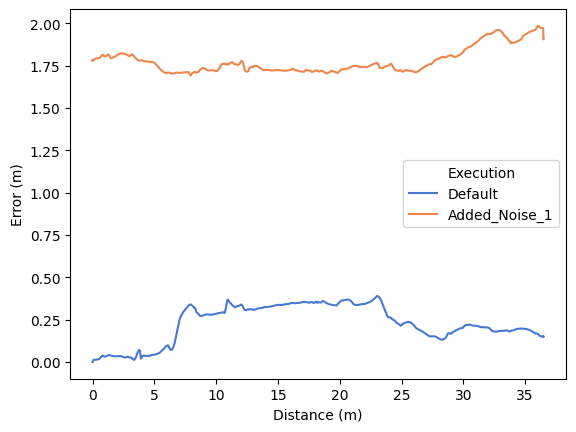

In [122]:
g = sns.lineplot(data = pd.concat([default_v2_01_easy_results_df, added_noise_v2_01_easy_results_df]), x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted')